# 딥러닝 학습 실습

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
import itertools

# 시드 고정
np.random.seed(42)
torch.manual_seed(42)

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


---
## 문제 1: 오버피팅 

### 1-1) 데이터셋 생성

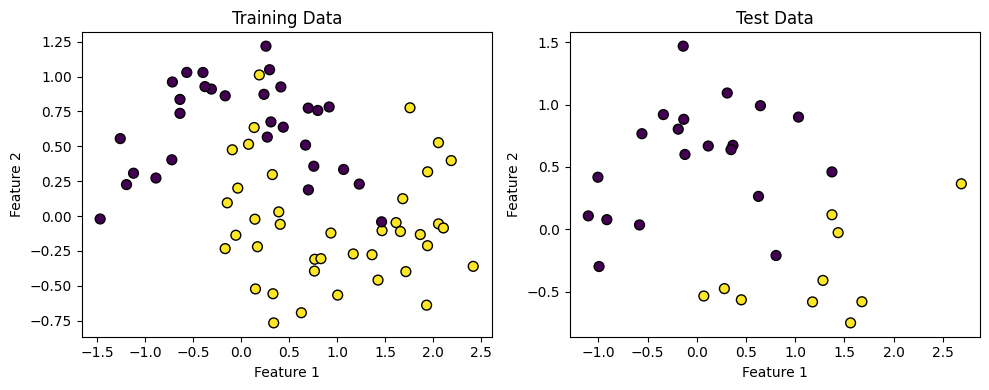

훈련 데이터: (70, 2), 테스트 데이터: (30, 2)


In [2]:
# 작은 데이터셋 생성 (오버피팅을 위해)
X, y = make_moons(n_samples=100, noise=0.25, random_state=42)

# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 데이터 시각화
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50)
plt.title('Training Data', fontsize=12)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=50)
plt.title('Test Data', fontsize=12)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

print(f"훈련 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

### 1-2) 오버피팅 유도

In [3]:
class OverfittingNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[64, 64, 64], output_dim=1):
        """
        복잡한 네트워크 구현
        """
        super(OverfittingNetwork, self).__init__()
        
        layers = []
        dims = [input_dim] + hidden_dims
        
        # 은닉층 구성
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.ReLU())       
            # layers.append(______())  # 빈칸 1: 활성화 함수
        
        # 출력층
        layers.append(nn.Linear(dims[-1], output_dim))
        layers.append(nn.Sigmoid())
        # layers.append(nn.______())  # 빈칸 2: 이진 분류용 출력 활성화 함수
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_model(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01, verbose=True):
    """
    모델 학습 함수
    """
    criterion = nn.BCELoss()
    # criterion = nn.______()  # 빈칸 3: 이진 분류 손실 함수
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # 학습 모드
        model.trian()
        # model.______()  # 빈칸 4: 학습 모드 설정
        optimizer.zero_grad()
        
        # 순전파
        outputs = model(X_train).squeeze()
        train_loss = criterion(outputs, y_train)
        
        # 역전파
        train_loss.backward()
        # train_loss.______()  # 빈칸 5: 역전파
        optimizer.step()
        
        # 평가 모드
        model.eval()
        # model.______()  # 빈칸 6: 평가 모드 설정
        with torch.no_grad():
            test_outputs = model(X_test).squeeze()
            test_loss = criterion(test_outputs, y_test)
        
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}")
    
    return train_losses, test_losses

# 매우 복잡한 모델 생성
model = OverfittingNetwork(input_dim=2, hidden_dims=[64, 64, 64], output_dim=1).to(device)
print("\n=== 모델 구조 ===")
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters())}")

# 학습 수행
print("\n=== 학습 시작 ===")
train_losses, test_losses = train_model(model, X_train_tensor, y_train_tensor, 
                                        X_test_tensor, y_test_tensor, 
                                        epochs=500, lr=0.1)


=== 모델 구조 ===
OverfittingNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

총 파라미터 수: 8577

=== 학습 시작 ===


AttributeError: 'OverfittingNetwork' object has no attribute 'trian'

### 1-3) 오버피팅 시각화

In [ ]:
# 학습 곡선 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2, color='blue')
plt.plot(test_losses, label='Test Loss', linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('오버피팅 관찰: Training vs Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# 결정 경계 시각화
plt.subplot(1, 2, 2)
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

model.eval()
with torch.no_grad():
    Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)).cpu().numpy()
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', 
           edgecolors='k', s=50, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', 
           marker='s', edgecolors='red', s=80, linewidths=2, label='Test')
plt.title('결정 경계 (Decision Boundary)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()
plt.show()

print("\n💡 관찰:")
print("1. Training loss는 계속 감소")
print("2. Test loss는 어느 시점부터 증가 → 오버피팅!")
print("3. 결정 경계가 훈련 데이터에 과도하게 맞춰짐")
print(f"\n최종 Train Loss: {train_losses[-1]:.4f}")
print(f"최종 Test Loss: {test_losses[-1]:.4f}")
print(f"Overfitting Gap: {test_losses[-1] - train_losses[-1]:.4f}")

---
## 문제 2: Weight Decay 구현

In [ ]:
def train_with_weight_decay(model, X_train, y_train, X_test, y_test, 
                           epochs=500, lr=0.01, weight_decay=0.01, verbose=True):
    """
    Weight Decay를 적용한 학습
    """
    criterion = nn.BCELoss()
    # weight_decay 파라미터로 L2 정규화 적용
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    # optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=______)  # 빈칸 7: weight_decay 파라미터
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train).squeeze()
        train_loss = criterion(outputs, y_train)
        
        train_loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test).squeeze()
            test_loss = criterion(test_outputs, y_test)
        
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train: {train_loss.item():.4f}, Test: {test_loss.item():.4f}")
    
    return train_losses, test_losses

# 다양한 weight_decay 값으로 실험
results = {}
weight_decays = [0, 0.001, 0.01, 0.1]

for wd in weight_decays:
    print(f"\n=== Weight Decay = {wd} ===")
    model_wd = OverfittingNetwork(input_dim=2, hidden_dims=[64, 64, 64], output_dim=1).to(device)
    train_loss, test_loss = train_with_weight_decay(model_wd, X_train_tensor, y_train_tensor,
                                                    X_test_tensor, y_test_tensor,
                                                    epochs=500, lr=0.1, weight_decay=wd)
    results[wd] = {'train': train_loss, 'test': test_loss}

In [ ]:
# Weight Decay 효과 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for wd in weight_decays:
    plt.plot(results[wd]['train'], label=f'λ={wd}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Train Loss', fontsize=12)
plt.title('Weight Decay 효과: Train Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for wd in weight_decays:
    plt.plot(results[wd]['test'], label=f'λ={wd}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Loss', fontsize=12)
plt.title('Weight Decay 효과: Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 비교 표
print("\n" + "="*60)
print("=== Weight Decay 최종 성능 비교 ===")
print("="*60)
print(f"{'λ':>8} {'Train Loss':>14} {'Test Loss':>14} {'Gap':>14}")
print("-"*60)
for wd in weight_decays:
    train_final = results[wd]['train'][-1]
    test_final = results[wd]['test'][-1]
    gap = test_final - train_final
    print(f"{wd:>8.3f} {train_final:>14.4f} {test_final:>14.4f} {gap:>14.4f}")
print("="*60)

print("\n💡 결론:")
print("1. Weight Decay가 클수록 오버피팅 감소")
print("2. 너무 크면 언더피팅 발생 가능 (학습이 느려짐)")
print("3. 적절한 값(0.01~0.001) 선택이 중요")

---
## 문제 3: Dropout 구현

In [ ]:
class NetworkWithDropout(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[64, 64, 64], output_dim=1, dropout_rate=0.5):
        """
        Dropout을 적용한 신경망
        """
        super(NetworkWithDropout, self).__init__()
        
        layers = []
        dims = [input_dim] + hidden_dims
        
        # 은닉층 구성 (Dropout 포함)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            # layers.append(nn.______(dropout_rate))  # 빈칸 8: Dropout 레이어
        
        # 출력층 (Dropout 없음)
        layers.append(nn.Linear(dims[-1], output_dim))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# 다양한 dropout_rate로 실험
dropout_results = {}
dropout_rates = [0.0, 0.3, 0.5, 0.7]

for dr in dropout_rates:
    print(f"\n=== Dropout Rate = {dr} ===")
    model_dr = NetworkWithDropout(input_dim=2, hidden_dims=[64, 64, 64], 
                                  output_dim=1, dropout_rate=dr).to(device)
    train_loss, test_loss = train_model(model_dr, X_train_tensor, y_train_tensor,
                                       X_test_tensor, y_test_tensor,
                                       epochs=500, lr=0.1)
    dropout_results[dr] = {'train': train_loss, 'test': test_loss}

In [ ]:
# Dropout 효과 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for dr in dropout_rates:
    plt.plot(dropout_results[dr]['train'], label=f'p={dr}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Train Loss', fontsize=12)
plt.title('Dropout 효과: Train Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for dr in dropout_rates:
    plt.plot(dropout_results[dr]['test'], label=f'p={dr}', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Loss', fontsize=12)
plt.title('Dropout 효과: Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 비교
print("\n" + "="*60)
print("=== Dropout 최종 성능 비교 ===")
print("="*60)
print(f"{'Dropout':>10} {'Train Loss':>14} {'Test Loss':>14} {'Gap':>14}")
print("-"*60)
for dr in dropout_rates:
    train_final = dropout_results[dr]['train'][-1]
    test_final = dropout_results[dr]['test'][-1]
    gap = test_final - train_final
    print(f"{dr:>10.1f} {train_final:>14.4f} {test_final:>14.4f} {gap:>14.4f}")
print("="*60)

print("\n💡 결론:")
print("1. Dropout은 훈련 시 무작위로 뉴런을 비활성화")
print("2. 앙상블 효과로 오버피팅 감소")
print("3. 0.3~0.5가 일반적으로 좋은 선택")
print("4. 너무 높으면 학습 능력 저하")

---
## 문제 4: Batch Normalization 구현

In [ ]:
class NetworkWithBatchNorm(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[64, 64, 64], output_dim=1):
        """
        Batch Normalization을 적용한 신경망
        """
        super(NetworkWithBatchNorm, self).__init__()
        
        layers = []
        dims = [input_dim] + hidden_dims
        
        # 은닉층 구성 (BatchNorm 포함)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d)
            # layers.append(nn.______1d(dims[i+1]))  # 빈칸 9: Batch Normalization 레이어
            layers.append(nn.ReLU())
        
        # 출력층
        layers.append(nn.Linear(dims[-1], output_dim))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# BatchNorm 효과 실험
print("=== BatchNorm 없는 깊은 네트워크 ===")
model_no_bn = OverfittingNetwork(input_dim=2, hidden_dims=[32, 32, 32, 32, 32], output_dim=1).to(device)
train_no_bn, test_no_bn = train_model(model_no_bn, X_train_tensor, y_train_tensor,
                                      X_test_tensor, y_test_tensor,
                                      epochs=300, lr=0.01)

print("\n=== BatchNorm 있는 깊은 네트워크 ===")
model_with_bn = NetworkWithBatchNorm(input_dim=2, hidden_dims=[32, 32, 32, 32, 32], output_dim=1).to(device)
train_with_bn, test_with_bn = train_model(model_with_bn, X_train_tensor, y_train_tensor,
                                          X_test_tensor, y_test_tensor,
                                          epochs=300, lr=0.1)  # 더 높은 학습률 사용 가능

In [ ]:
# BatchNorm 효과 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_no_bn, label='Without BN (lr=0.01)', linewidth=2)
plt.plot(train_with_bn, label='With BN (lr=0.1)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Train Loss', fontsize=12)
plt.title('BatchNorm 효과: Train Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(test_no_bn, label='Without BN (lr=0.01)', linewidth=2)
plt.plot(test_with_bn, label='With BN (lr=0.1)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Loss', fontsize=12)
plt.title('BatchNorm 효과: Test Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 관찰:")
print("1. BN을 사용하면 학습 속도가 크게 빨라짐")
print("2. 더 높은 학습률 사용 가능 (0.01 → 0.1)")
print("3. 초기 가중치에 덜 민감함")
print("4. 깊은 네트워크에서 특히 효과적")
print(f"\nWithout BN - 최종 Test Loss: {test_no_bn[-1]:.4f}")
print(f"With BN    - 최종 Test Loss: {test_with_bn[-1]:.4f}")

---
## 문제 5: Early Stopping 구현

In [ ]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
            # if self.counter >= self.______:  # 빈칸 10: patience 값 확인
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
        
        return self.early_stop
    
    def save_checkpoint(self, model):
        self.best_model = copy.deepcopy(model.state_dic())
        # self.best_model = copy.deepcopy(model.______)  # 빈칸 11: 모델 상태 저장
    
    def load_best_model(self, model):
        model.load_state_dic(self.best_model)
        # model.______(self.best_model)  # 빈칸 12: 최고 모델 불러오기

def train_with_early_stopping(model, X_train, y_train, X_val, y_val, 
                              epochs=500, lr=0.1, patience=30):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    early_stopping = EarlyStopping(patience=patience, verbose=False)
    # early_stopping = EarlyStopping(patience=______, verbose=False)  # 빈칸 13: patience 설정
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train).squeeze()
        train_loss = criterion(outputs, y_train)
        
        train_loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val).squeeze()
            val_loss = criterion(val_outputs, y_val)
        
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Train: {train_loss.item():.4f}, Val: {val_loss.item():.4f}")
        
        if early_stopping(val_loss.item(), model):
            print(f"\n✓ Early stopping at epoch {epoch+1}!")
            print(f"Best val loss: {early_stopping.best_loss:.4f}")
            break
    
    # 최고 모델 복원
    early_stopping.load_best_model(model)
    
    return train_losses, val_losses

# Validation set 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_tr_tensor = torch.FloatTensor(X_tr).to(device)
y_tr_tensor = torch.FloatTensor(y_tr).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

print("=== Early Stopping 없음 ===")
model_no_es = OverfittingNetwork(input_dim=2, hidden_dims=[64, 64, 64], output_dim=1).to(device)
train_no_es, val_no_es = train_model(model_no_es, X_tr_tensor, y_tr_tensor,
                                     X_val_tensor, y_val_tensor,
                                     epochs=500, lr=0.1, verbose=False)

print("\n=== Early Stopping 있음 ===")
model_with_es = OverfittingNetwork(input_dim=2, hidden_dims=[64, 64, 64], output_dim=1).to(device)
train_with_es, val_with_es = train_with_early_stopping(model_with_es, X_tr_tensor, y_tr_tensor,
                                                        X_val_tensor, y_val_tensor,
                                                        epochs=500, lr=0.1, patience=30)

In [ ]:
# Early Stopping 효과 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_no_es, label='Train (No ES)', linewidth=2, alpha=0.7)
plt.plot(val_no_es, label='Val (No ES)', linewidth=2, linestyle='--', alpha=0.7)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Without Early Stopping', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_with_es, label='Train (With ES)', linewidth=2, alpha=0.7)
plt.plot(val_with_es, label='Val (With ES)', linewidth=2, linestyle='--', alpha=0.7)
plt.axvline(len(train_with_es), color='red', linestyle=':', linewidth=2, label='Stopped Here')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('With Early Stopping', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Early Stopping으로 {500 - len(train_with_es)} epochs 절약!")
print(f"Without ES - 최종 Val Loss: {val_no_es[-1]:.4f}")
print(f"With ES    - 최종 Val Loss: {val_with_es[-1]:.4f}")
print(f"개선: {val_no_es[-1] - val_with_es[-1]:.4f}")